# Lab D &mdash; Work

In this computer exercise we will look at
<ul>
    <li>Image blending</li>
    <li>Separable convolutions in 2D</li>
    <li>Gaussian and Laplacian pyramids</li>
</ul>


###  Fetching and loading the images

In this computer exercise, we will use use some example images, which can be fetched from Lisam.
In most cases, Jupyter Notebook will find the images if they are in the same directory as the notebook file.
In the rare cases where this does not work, you can always supply the full path to the images instead of only the file name.


### A note on mandatory teacher interaction
At some places (marked clearly in $\color{red}{\text{red}}$) in the computer exercise you will be informed that teacher interaction is required.
Typically, you are expected to briefly explain your observations and reasoning for that section to the teacher.
Once you reach a point where teacher interaction is required, reflect a little on what occurred in that section, and then notify a teacher.
You do not have to just sit around and wait for the teacher interaction before you continue, e.g. if all teachers are busy, but do not postpone all interaction to the end of the lab.


### Acknowledgement
A proof-of-concept implementation of the Laplacian image blending in this lab was implemented by Ziliang Xiong.

In [1]:
### Import python modules for linear algebra (numpy) and plotting (matplotlib).

import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve2d
from scipy.signal.windows import gaussian

%matplotlib inline
np.set_printoptions(precision = 2, suppress = True)

## 1. Direct binary image blending

Suppose we want to blend two images $A$ and $B$ together, according to a provided binary <i>blending mask</i> $M$.
Let us assume the two images, as well as the blending mask, are of the same size.
The direct blending approach simply uses the blending mask to determine, for each pixel, whether to copy the image content from image $A$ or from image $B$.
The blended image $C$ is thus determined by

$$
    C_{ij} = (1-M_{ij})A + M_{ij}B.
$$

As one might suspect, direct blending is not a very sophisticated approach, and it rarely looks good.


### Task: Try direct binary image blending on some example images.

<ul>
    <li>Try, e.g., blending the apple and orange images according to <code>mask3.png</code> or <code>mask.png</code>.</li>
    <li>Try, e.g., blending the hand and eye images according to <code>mask3.png</code>.</li>
    <li>You can either loop through the RGB channels and apply the mask, loop through the pixel positions and select the desired colour, or you can extend the mask to RGB using <code>np.tile</code>.</li>
    <li>Due to rounding errors etc., it may be useful to use <code>np.clip</code> to ensure that the blended image is strictly in the range $[0,1]$.</li>
</ul>

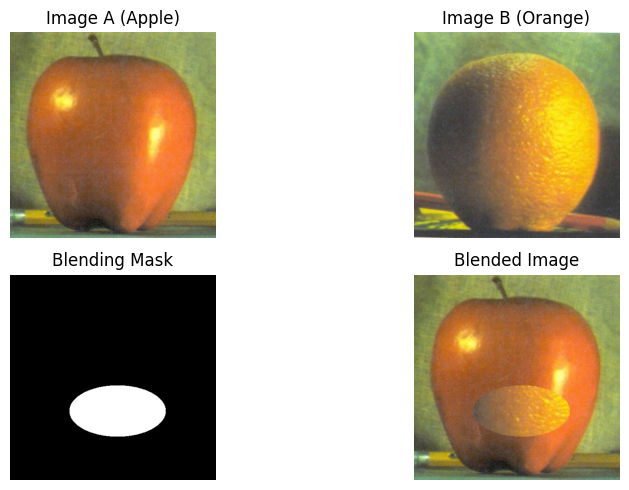

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Implement a function that blends image A and image B according to mask M.
def blend_images(A, B, M):
    """Blend images A and B according to the mask M.
    Parameters:A, B : numpy arrays:The input images to be blended (assumed to be of the same size and color channels).
    M : numpy array:The blending mask (values between 0 and 1).
    Returns:numpy array:The blended image.
    """
    # Ensure mask M is scaled between 0 and 1
    M = np.clip(M, 0, 1)
    
    # If M is single-channel, make it compatible with A and B by expanding its dimensions
    if M.ndim == 2:
        M = np.stack([M]*3, axis=-1)  # Stack M to have 3 channels
    
    # Perform the blending operation
    C = (1 - M) * A + M * B
    
    # Clip values to the valid range [0, 1]
    C = np.clip(C, 0, 1)

    return C

# Load the apple and orange images.
A = plt.imread('apple.png')
B = plt.imread('orange.png')
M = plt.imread('mask3.png')

# Normalize images and mask if needed
if A.max() > 1:
    A = A / 255.0
if B.max() > 1:
    B = B / 255.0
if M.max() > 1:
    M = M / 255.0

# Show the images, mask, and blended result
plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(A)
plt.title("Image A (Apple)")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(B)
plt.title("Image B (Orange)")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(M, cmap='gray')
plt.title("Blending Mask")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(blend_images(A, B, M))
plt.title("Blended Image")
plt.axis('off')

plt.tight_layout()
plt.show()


### 1.1. Blending using a smoothed mask

The sharp <i>seam</i> (the transition border) does not look very good.
An obvious improvement would be to depart from the <i>binary</i> blending masks, and instead allow smooth blending masks.
In this case, the blended image $C$ is still determined by

$$
    C_{ij} = (1-M_{ij})A + M_{ij}B,
$$

but the mask $M$ is now allowed to contain values in the interval $[0,1]$.
If you implemented <code>blend_images</code> in a sensible way, it should immediately work for this case too.

Blending using a smoothed mask can actually give visually pleasant results in many cases, if we smooth the kernel enough.

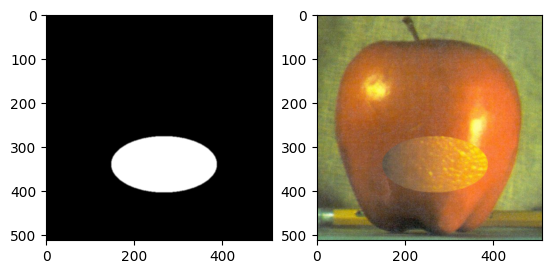

In [3]:
# Smooth the mask using an averaging kernel. Increase the kernel size until the blending looks good.
K = np.ones((3,3))
K = K/K.sum()
Msmooth = convolve2d(M,K,'same')


# Show the images, mask, and blended result.
plt.figure()
plt.subplot(1,2,1)
plt.imshow(Msmooth)
plt.gray()
plt.subplot(1,2,2)
plt.imshow(blend_images(A,B,Msmooth))
plt.show()

### 1.2. Exploiting separability to speed up the convolution

Using <code>convolve2d</code> (from <code>scipy.signal</code>) according to the previous section became unbearably slow for large kernel sizes.
If the convolution kernel is separable, i.e. $K(u,v) = K_x(u)K_y(v)$, this can be ameliorated, as we can achieve exactly the same result by convolving with two one-dimensional convolution kernels (one in the $x$ direction, and one in the $y$ direction).


### Task: Implement a separable 2D convolution

<ul>
    <li>Implement a separable 2D convolution and test its correctness and timing statistics in the following two cells.</li>
    <li>You can still use <code>convolve2d</code> from <code>scipy.signal</code>, but your kernels must be 1D.</li>
    <li><b>Note:</b> $\color{red}{\text{Show your work and discuss with a teacher!}}$</li>
</ul>

In [4]:
def separable_convolve2d(M, Kx, Ky, mode='same'):
    """Perform a separable 2D convolution using two 1D kernels (Kx and Ky).
    Parameters:M : 2D numpy array&&The input matrix (image) to convolve.
    Kx : 1D numpy array&&The horizontal kernel (row-wise).
    Ky : 1D numpy array&&The vertical kernel (column-wise).
    mode : str&&The mode for convolution, same as in scipy.signal.convolve2d.
    Returns:2D numpy array&&The convolved result."""
    # Perform horizontal convolution (Kx as a 2D row vector)
    M = convolve2d(M, Kx, mode=mode)  # Convolve along rows
    # Perform vertical convolution (Ky as a 2D column vector)
    M = convolve2d(M, Ky, mode=mode)  # Convolve along columns
    return M

In [5]:
# Compare the separable 2D convolution to the naïve approach.
for s in [3,7,21,71]:
    # Create the convolution kernels.
    Kx = np.ones((1,s))
    Kx = Kx/Kx.sum()
    Ky = Kx.T
    K = Ky @ Kx

    # Verify that the separable convolution gives the same result as the naïve computation.
    assert np.linalg.norm(separable_convolve2d(M,Kx,Ky)-convolve2d(M,K,'same'),'fro') < 1e-5

    # Print timing statistics.
    print(f'Naive     ({s}x{s}):\t', end='')
    %timeit convolve2d(M,K,'same')
    print(f'Separable ({s}x{s}):\t', end='')
    %timeit separable_convolve2d(M,Kx,Ky)

Naive     (3x3):	10.2 ms ± 577 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Separable (3x3):	10.3 ms ± 203 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Naive     (7x7):	39.9 ms ± 645 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Separable (7x7):	18.6 ms ± 423 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Naive     (21x21):	297 ms ± 7.17 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Separable (21x21):	50.2 ms ± 447 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Naive     (71x71):	3.79 s ± 51.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Separable (71x71):	175 ms ± 4.06 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## 2. Multi-resolution image blending (Burt &amp; Adelson)

While image blending with a very smooth kernel gave reasonably good results, it can still lead to undesirable &quot;double exposure&quot; artefacts (see e.g. Figure 3 in Burt &amp; Adelson).
The reason for this effect is that the blending seam is equally wide for all frequencies.

Burt &amp; Adelson proposed a method to address this issue by first separating the frequency content of the images into the different levels of the Laplacian pyramid, and performing frequency-aware blending for each level, before reassembling the final image.
The idea is simple, yet elegant:
<ul>
    <li>Compute Laplacian pyramids for the two images $A$ and $B$.</li>
    <li>Compute a Gaussian pyramid for the blending mask $M$.</li>
    <li>Compute a blended Laplacian pyramid, by blending the corresponding layers from the Laplacian pyramids of $A$ and $B$ according to the corresponding layer in the Gaussian pyramid of $M$.</li>
    <li>Reassemble the blended pyramid to form the blended image $C$.</li>
</ul>

### 2.1. Constructing the Gaussian and Laplacian pyramids

Since the Laplacian pyramid is obtained as the difference between consecutive levels in the Gaussian pyramid, it requires very little extra effort to compute both pyramids at the same time.

We will compute all levels in the pyramids, i.e. until the image has been downsampled to only one single pixel.


### Task: Find a suitable blurring value $s_0$, and compute the pyramids

<ul>
    <li>You need to choose $s_0$ large enough to avoid noticeable aliasing effects from the downsampling!</li>
    <li>Is there any drawback associated with choosing a too large $s_0$?</li>
    <li>Remember to use your <code>separable_convolve2d</code> to do the blurring!</li>
</ul>

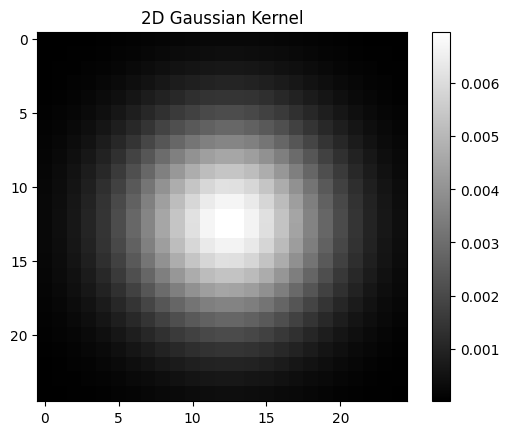

In [6]:
# Define Gaussian smoothing kernel (1D)
def gaussian(size, s0):
    """Generate a 1D Gaussian kernel."""
    t = np.linspace(-size // 2, size // 2, size)
    g = np.exp(-t**2 / (2 * s0**2))
    return g / g.sum()

# Visualize the Gaussian smoothing kernel
s0 = 5
Gx = gaussian(5 * s0, s0).reshape((5 * s0, 1))  # Horizontal kernel
Gx = Gx / Gx.sum()  # Normalize
Gy = Gx.T  # Vertical kernel (transpose)

plt.figure()
plt.imshow(Gx @ Gy)  # 2D Gaussian kernel visualization
plt.colorbar()
plt.title("2D Gaussian Kernel")
plt.show()

# Function to compute Gaussian and Laplacian pyramids
def compute_image_pyramids(I):
    """Computes the Gaussian and Laplacian pyramids for a given image I.
    Parameters:I: ndarrayInput image (grayscale or per-channel for RGB).
    Returns:(IG, IL): tuple IG: list of Gaussian pyramid layers.IL: list of Laplacian pyramid layers.
    """
    s0 = 5  # Smoothing kernel size
    size = 5 * s0  # Size of the Gaussian kernel
    Gx = gaussian(size, s0).reshape((size, 1))  # Horizontal kernel
    Gx = Gx / Gx.sum()  # Normalize
    Gy = Gx.T  # Vertical kernel

    # Initiate the lists
    IG, IL = ([I], [])  # Gaussian and Laplacian pyramids

    while min(IG[-1].shape) > 1:
        # Blur the current top layer of IG
        blurred = separable_convolve2d(IG[-1], Gx, Gy)
        diff=IG[-1]-blurred
         # Append the downsampled image to the Gaussian pyramid
        IL.append(diff)
        # Downsample the blurred image
        downsampled = blurred[::2, ::2]
        IG.append(downsampled)

    return IG, IL

# Example Usage
img = np.random.rand(256, 256)  # Example grayscale image
IG, IL = compute_image_pyramids(img)


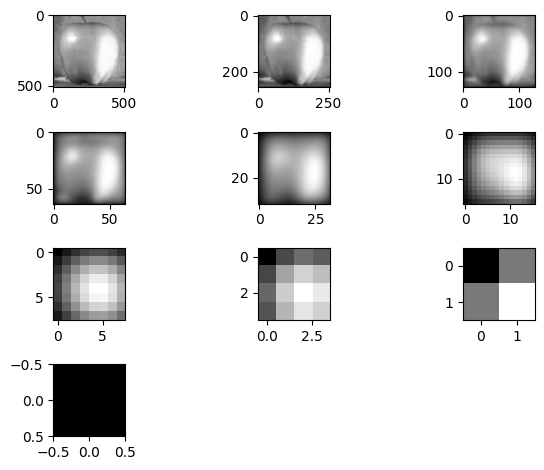

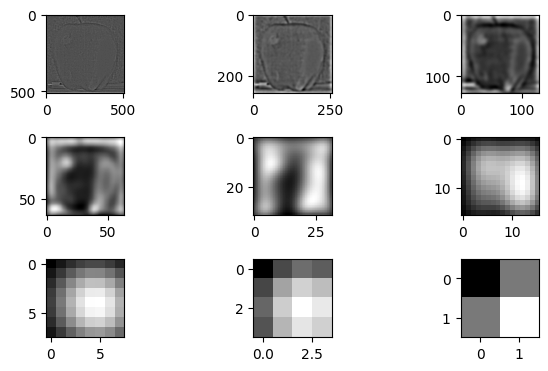

In [7]:
# Compute the image pyramids (for the red channel).
(AG,AL) = compute_image_pyramids(A[:,:,0])
cols = int(np.floor(np.sqrt(len(AG))))


# Show the Gaussian pyramid (for the red channel).
plt.figure()
for j in range(len(AG)):
    plt.subplot(len(AG)//cols+1,cols,j+1)
    plt.imshow(AG[j])
plt.tight_layout()
plt.show()


# Show the Laplacian pyramid (for the red channel).
plt.figure()
for j in range(len(AL)):
    plt.subplot(len(AG)//cols+1,cols,j+1)
    plt.imshow(AL[j])
plt.tight_layout()
plt.show()

### 2.2. Reassembling an image from its pyramid

As explained during the lecture, we can recover an image from its Laplacian pyramid together with the coarsest level of its Gaussian pyramid, by simply upsampling and summing it all together.

<ul>
    <li><b>Note:</b> $\color{red}{\text{There is currently a bug in the lab that causes the total intensity to be too low after reassembling in this way!}}$</li>
</ul>

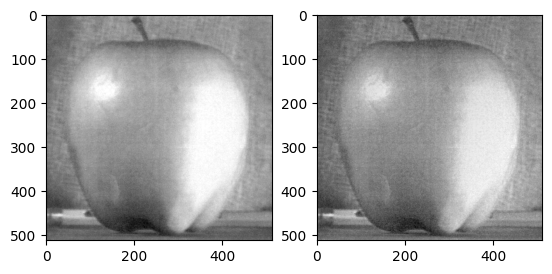

In [8]:
# Reassemble an image by summing the upsampled Laplacian pyramid and the coarsest Gaussian scale.
def reassemble(IGlast,IL):
    s0 = 5
    Gx = gaussian(5*s0,s0).reshape((5*s0,1))
    Gx = Gx/Gx.sum()
    Gy = Gx.T

    # Initialise the image to the coarsest Gaussian scale.
    I = IGlast

    # Upsample and add back the details from the Laplacian pyramid.
    for j in range(1,len(IL)+1):
        tmp = np.zeros((2*I.shape[0],2*I.shape[1]))
        tmp[::2,::2] = I
        tmp[1::2,::2] = I
        tmp[::2,1::2] = I
        tmp[1::2,1::2] = I
        I = separable_convolve2d(tmp,Gx,Gy)+IL[-j]

    return I

# Compare the original red channel with the reassembled one.
# Currently the reconstructed one is too dark.
plt.figure()
plt.subplot(1,2,1)
plt.imshow(A[:,:,0])
plt.subplot(1,2,2)
plt.imshow(reassemble(AG[-1],AL))
plt.show()

### 2.3. Putting things together


### Task: Merge the Laplacian pyramids according to the corresponding Gaussian pyramid of the mask

<ul>
    <li>We perform the blending separately in each colour channel.</li>
    <li>Loop through the levels of the Laplacian pyramids, and store the merged result in another list.</li>
    <li><b>Note:</b> $\color{red}{\text{Show your work and discuss with a teacher!}}$</li>
</ul>

range(0, 9)
range(0, 10)


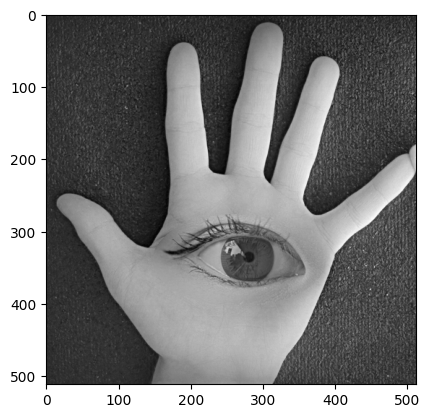

range(0, 9)
range(0, 10)


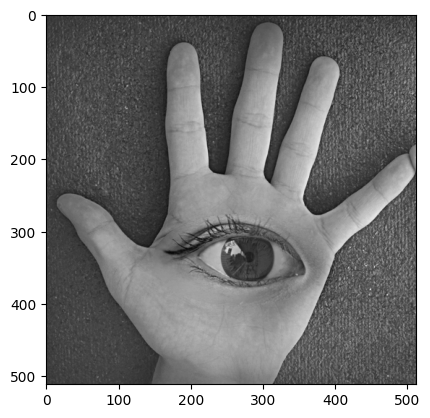

range(0, 9)
range(0, 10)


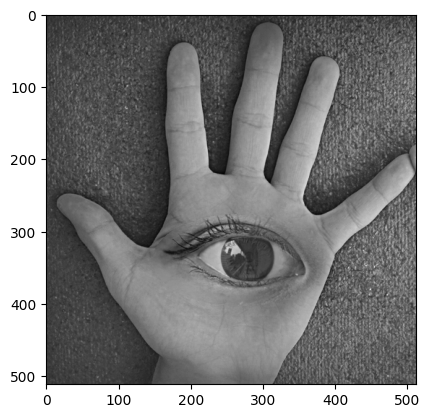

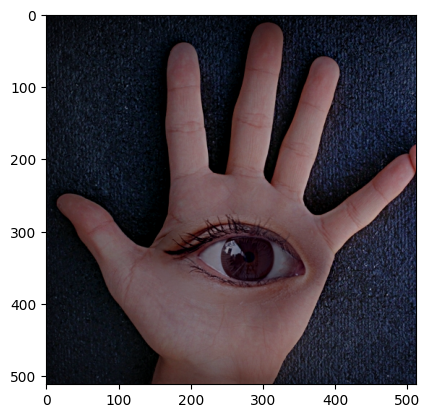

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Load images and mask.
A = plt.imread("hand.png")
B = plt.imread("eye.png")
M = plt.imread("mask3.png")  # Use mask 3

# Create a smoothing kernel.
K = np.ones((100, 100))
K = K / K.sum()
Msmooth = convolve2d(M, K, "same")

# Allocate an array to hold the result.
C = np.zeros(A.shape)

# Compute Gaussian pyramid of the mask.
(MG, _) = compute_image_pyramids(M)

for j in range(3):
    # For each color channel, create a blended pyramid
    # and use that to reassemble the blended image.
    (A_G, A_L) = compute_image_pyramids(A[:, :, j])
    (B_G, B_L) = compute_image_pyramids(B[:, :, j])
    print(range(len(A_L)))  # Check the pyramid levels for A
    print(range(len(MG)))   # Check the pyramid levels for M
    blended_levels = []

    # Create blended pyramid. Assuming len(A_L) = len(MG).
    for level in range(len(A_L)):
        blended_level = (1 - MG[level]) * A_L[level] + MG[level] * B_L[level]
        blended_levels.append(blended_level)
        
    reassembeled_C= reassemble(A_G[-1], blended_levels)     
    # Reassemble starting from the coarsest level.
    C[:, :, j] =  reassembeled_C
    plt.figure()
    plt.imshow(reassembeled_C)
    plt.show()


# Clip values to ensure they stay within [0, 1].
C = np.clip(C, 0, 1)

# Display the result.
plt.figure()
plt.imshow(C)
plt.show()


range(0, 9)
range(0, 10)


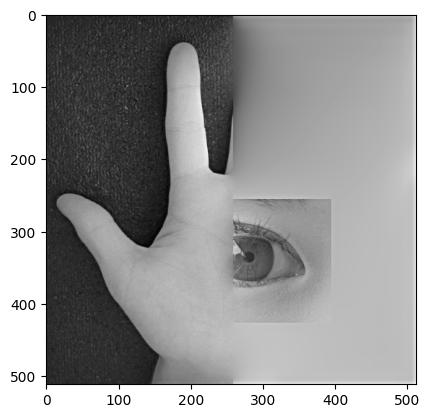

range(0, 9)
range(0, 10)


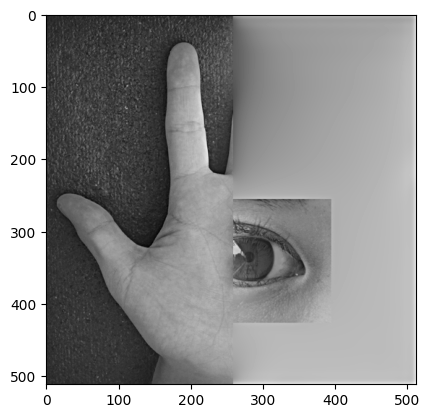

range(0, 9)
range(0, 10)


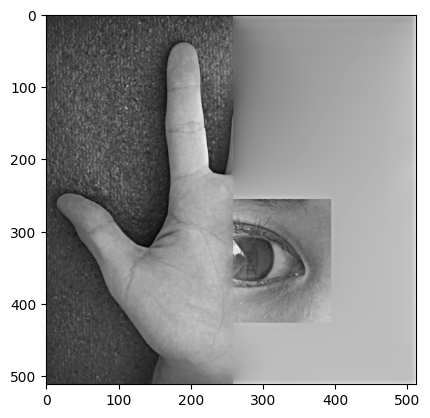

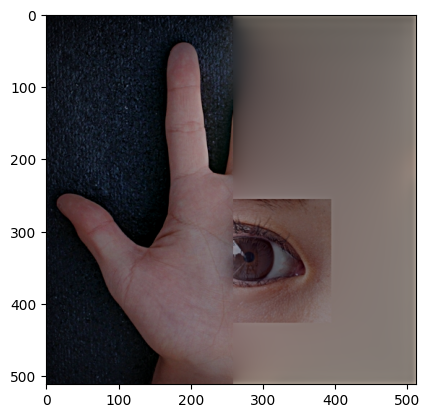

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Load images and mask.
A = plt.imread("hand.png")
B = plt.imread("eye.png")
M = plt.imread("mask.png")  # Use mask 3

# Create a smoothing kernel.
K = np.ones((100, 100)) / 10000  # Simplify by dividing directly
Msmooth = convolve2d(M, K, "same")

# Allocate an array to hold the result.
C = np.zeros_like(A)

# Compute Gaussian pyramid of the mask.
MG, _ = compute_image_pyramids(M)

# Iterate through color channels
for j in range(3):
    # Compute Gaussian and Laplacian pyramids for A and B
    A_G, A_L = compute_image_pyramids(A[:, :, j])
    B_G, B_L = compute_image_pyramids(B[:, :, j])
    
    print(range(len(A_L)))  # Check the pyramid levels for A
    print(range(len(MG)))   # Check the pyramid levels for M

    # Blend the pyramids
    blended_levels = [
        (1 - MG[level]) * A_L[level] + MG[level] * B_L[level]
        for level in range(len(A_L))
    ]

    # Reassemble the blended image for this channel
    reassembled_C = reassemble(A_G[-1], blended_levels)
    C[:, :, j] = reassembled_C

    # Display intermediate result
    plt.figure()
    plt.imshow(reassembled_C)
    plt.show()

# Clip values to ensure they stay within [0, 1].
C = np.clip(C, 0, 1)

# Display the final result.
plt.figure()
plt.imshow(C)
plt.show()


range(0, 9)
range(0, 10)


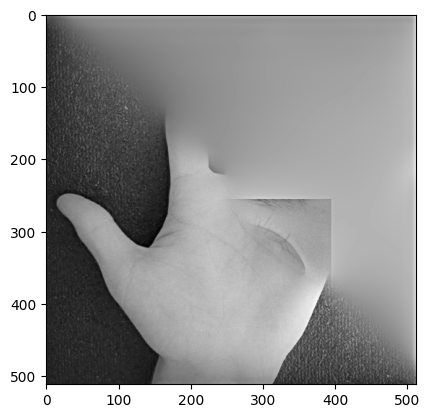

range(0, 9)
range(0, 10)


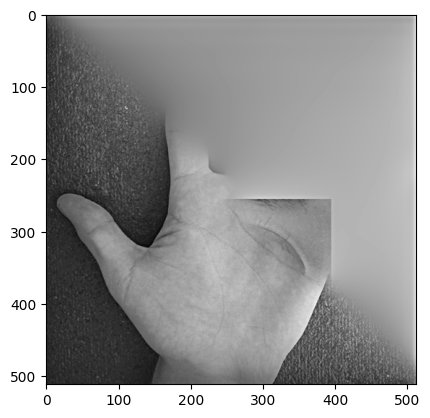

range(0, 9)
range(0, 10)


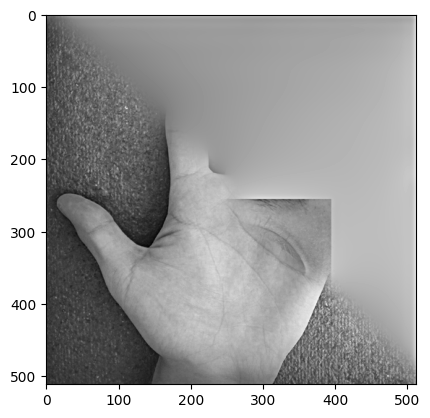

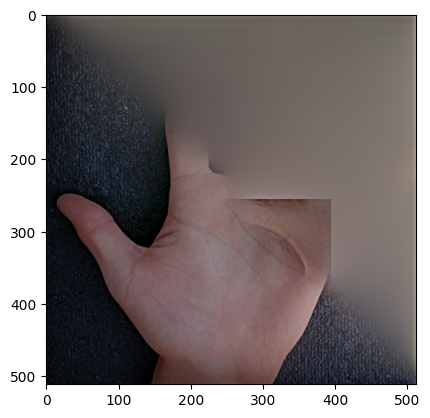

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Load images and mask.
A = plt.imread("hand.png")
B = plt.imread("eye.png")
M = plt.imread("mask2.png")  # Use mask 3

# Create a smoothing kernel.
K = np.ones((100, 100)) / 10000  # Simplify by dividing directly
Msmooth = convolve2d(M, K, "same")

# Allocate an array to hold the result.
C = np.zeros_like(A)

# Compute Gaussian pyramid of the mask.
MG, _ = compute_image_pyramids(M)

# Iterate through color channels
for j in range(3):
    # Compute Gaussian and Laplacian pyramids for A and B
    A_G, A_L = compute_image_pyramids(A[:, :, j])
    B_G, B_L = compute_image_pyramids(B[:, :, j])
    
    print(range(len(A_L)))  # Check the pyramid levels for A
    print(range(len(MG)))   # Check the pyramid levels for M

    # Blend the pyramids
    blended_levels = [
        (1 - MG[level]) * A_L[level] + MG[level] * B_L[level]
        for level in range(len(A_L))
    ]

    # Reassemble the blended image for this channel
    reassembled_C = reassemble(A_G[-1], blended_levels)
    C[:, :, j] = reassembled_C

    # Display intermediate result
    plt.figure()
    plt.imshow(reassembled_C)
    plt.show()

# Clip values to ensure they stay within [0, 1].
C = np.clip(C, 0, 1)

# Display the final result.
plt.figure()
plt.imshow(C)
plt.show()


range(0, 9)
range(0, 10)


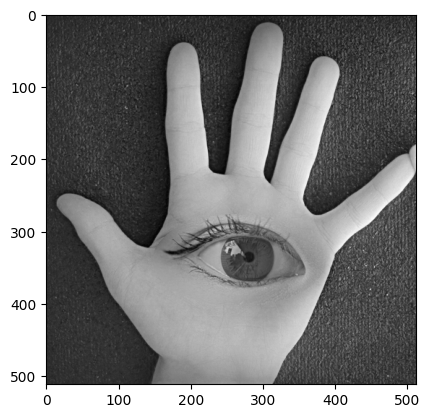

range(0, 9)
range(0, 10)


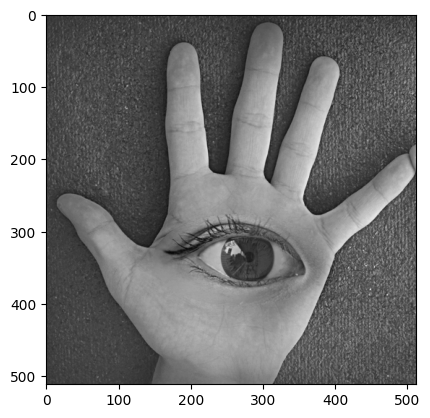

range(0, 9)
range(0, 10)


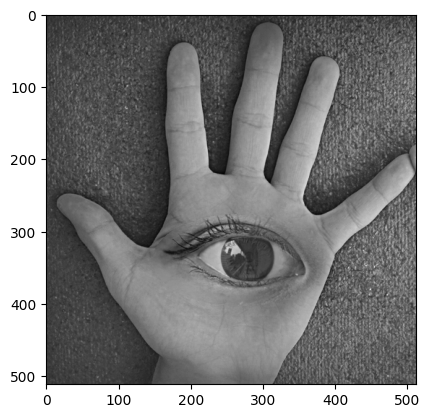

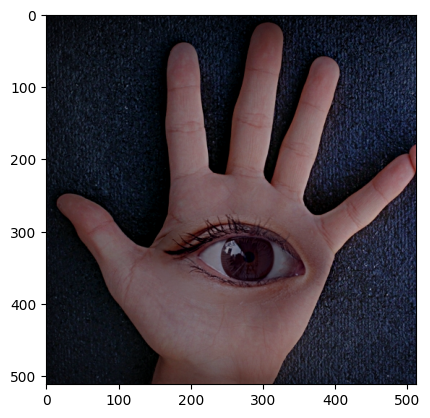

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Load images and mask.
A = plt.imread("hand.png")
B = plt.imread("eye.png")
M = plt.imread("mask3.png")  # Use mask 3

# Create a smoothing kernel.
K = np.ones((100, 100)) / 10000  # Simplify by dividing directly
Msmooth = convolve2d(M, K, "same")

# Allocate an array to hold the result.
C = np.zeros_like(A)

# Compute Gaussian pyramid of the mask.
MG, _ = compute_image_pyramids(M)

# Iterate through color channels
for j in range(3):
    # Compute Gaussian and Laplacian pyramids for A and B
    A_G, A_L = compute_image_pyramids(A[:, :, j])
    B_G, B_L = compute_image_pyramids(B[:, :, j])
    
    print(range(len(A_L)))  # Check the pyramid levels for A
    print(range(len(MG)))   # Check the pyramid levels for M

    # Blend the pyramids
    blended_levels = [
        (1 - MG[level]) * A_L[level] + MG[level] * B_L[level]
        for level in range(len(A_L))
    ]

    # Reassemble the blended image for this channel
    reassembled_C = reassemble(A_G[-1], blended_levels)
    C[:, :, j] = reassembled_C

    # Display intermediate result
    plt.figure()
    plt.imshow(reassembled_C)
    plt.show()

# Clip values to ensure they stay within [0, 1].
C = np.clip(C, 0, 1)

# Display the final result.
plt.figure()
plt.imshow(C)
plt.show()


range(0, 9)
range(0, 10)


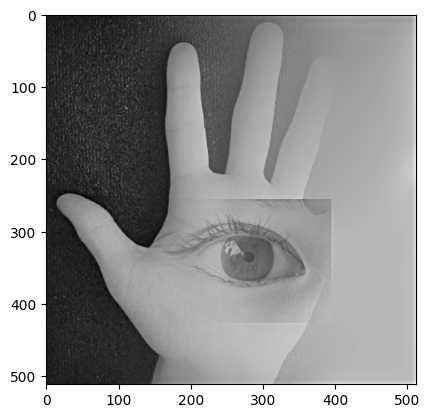

range(0, 9)
range(0, 10)


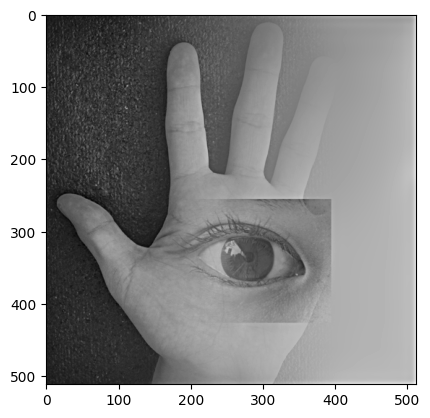

range(0, 9)
range(0, 10)


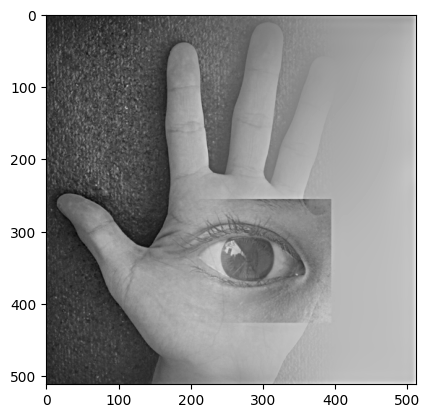

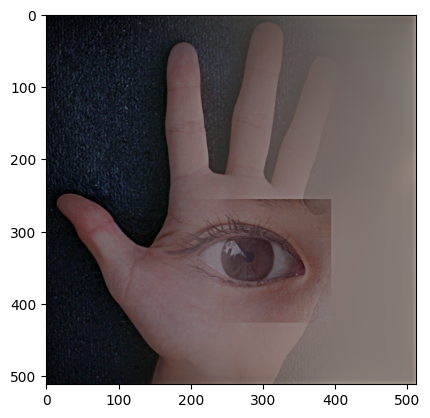

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Load images and mask.
A = plt.imread("hand.png")
B = plt.imread("eye.png")
M = plt.imread("mask4.png")  # Use mask 3

# Create a smoothing kernel.
K = np.ones((100, 100)) / 10000  # Simplify by dividing directly
Msmooth = convolve2d(M, K, "same")

# Allocate an array to hold the result.
C = np.zeros_like(A)

# Compute Gaussian pyramid of the mask.
MG, _ = compute_image_pyramids(M)

# Iterate through color channels
for j in range(3):
    # Compute Gaussian and Laplacian pyramids for A and B
    A_G, A_L = compute_image_pyramids(A[:, :, j])
    B_G, B_L = compute_image_pyramids(B[:, :, j])
    
    print(range(len(A_L)))  # Check the pyramid levels for A
    print(range(len(MG)))   # Check the pyramid levels for M

    # Blend the pyramids
    blended_levels = [
        (1 - MG[level]) * A_L[level] + MG[level] * B_L[level]
        for level in range(len(A_L))
    ]

    # Reassemble the blended image for this channel
    reassembled_C = reassemble(A_G[-1], blended_levels)
    C[:, :, j] = reassembled_C

    # Display intermediate result
    plt.figure()
    plt.imshow(reassembled_C)
    plt.show()

# Clip values to ensure they stay within [0, 1].
C = np.clip(C, 0, 1)

# Display the final result.
plt.figure()
plt.imshow(C)
plt.show()
